In [7]:
from __future__ import annotations

import os
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import xarray as xr
from scipy.stats import ttest_1samp

import matplotlib.pyplot as plt

from matplotlib.patches import Polygon
from matplotlib.colors import Normalize
from matplotlib.colors import BoundaryNorm, ListedColormap, LinearSegmentedColormap
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import FixedLocator


from DataUtil import (
    build_experiments,
    DEFAULT_EXPERIMENTS
)

from ObsUtil import (
    OBS_REGISTRY,
    get_obs_file,
    list_obs_sources,
    obs_coverage,
)

In [20]:

@dataclass(frozen=True)
class FileCollectionConfig:
    group: str
    freq: str
    run: str
    obs: str
    period: str
    model_template: str
    ens_prefix: str = "en"
    ens_width: int = 2
    ens_start: int = 1

    def parse_period(self) -> Tuple[int, int, int, int]:
        m = re.match(r"^(\d{4})(\d{2})-(\d{4})(\d{2})$", self.period)
        if not m:
            raise ValueError(f"Bad period '{self.period}', expected 'YYYYMM-YYYYMM'")
        y0, m0, y1, m1 = map(int, m.groups())
        if (y1, m1) < (y0, m0):
            raise ValueError(f"Bad period '{self.period}' (end < start)")
        return y0, m0, y1, m1

    def years(self) -> List[int]:
        y0, _, y1, _ = self.parse_period()
        return list(range(y0, y1 + 1))

    def ens_labels(self, nens: int) -> List[str]:
        return [
            f"{self.ens_prefix}{i:0{self.ens_width}d}"
            for i in range(self.ens_start, nens + self.ens_start)
        ]


class S2SFileCollector:
    """
    Collect obs + model files for S2S / diagnostics.

    s2s_var_dict: dict[model_var] -> obs_var
    """

    def __init__(
        self,
        *,
        exp_list: dict,
        exp_dict: dict,
        obs_registry,
        s2s_var_dict: Dict[str, str],
        get_obs_file_func,
    ):
        self.exp_list = exp_list
        self.exp_dict = exp_dict
        self.obs_registry = obs_registry
        self.s2s_var_dict = s2s_var_dict
        self.get_obs_file = get_obs_file_func

    def resolve_obs_file(self, obs: str, freq: str, year: int, var: Optional[str] = None) -> str:
        return self.get_obs_file(self.obs_registry, obs, freq=freq, year=year, var=var)

    def model_ts_dir(self, run_meta, freq: str) -> str:
        # NOTE: land path for land variables
        return os.path.join(run_meta.lnd_path, "ts", freq)

    def model_files_for_ens(
        self,
        cfg: FileCollectionConfig,
        *,
        run_meta,
        var: str,
        ens: str,
    ) -> List[str]:
        ts_dir = self.model_ts_dir(run_meta, cfg.freq)
        years = cfg.years()
        return [
            os.path.join(
                ts_dir,
                cfg.model_template % {"var": var, "ens": ens, "year": y, "period": cfg.period},
            )
            for y in years
        ]

    def collect_one_var(self, cfg: FileCollectionConfig, *, var: str, obs_var: str, verbose: bool = True):
        years = cfg.years()
        models = self.exp_list[cfg.group]["models"]

        # obs files
        obs_files = [self.resolve_obs_file(cfg.obs, cfg.freq, y, obs_var) for y in years]
        missing_obs = [f for f in obs_files if not os.path.exists(f)]
        if missing_obs:
            if verbose:
                print(f"[MISSING OBS] {var} (obs_var={obs_var})")
                for f in missing_obs:
                    print("  ", f)
            return None

        out_var = {}

        for exp in models:
            run_meta = self.exp_dict[exp]["runs"][cfg.run]
            if run_meta is None:
                if verbose:
                    print(f"SKIP {exp}: no run='{cfg.run}'")
                continue

            nens = int(self.exp_dict[exp]["nens"])
            ts_dir = self.model_ts_dir(run_meta, cfg.freq)

            model_by_ens = {}
            missing_any = False

            for ens in cfg.ens_labels(nens):
                files = self.model_files_for_ens(cfg, run_meta=run_meta, var=var, ens=ens)

                missing = [f for f in files if not os.path.exists(f)]
                if missing:
                    missing_any = True
                    if verbose:
                        print(f"[MISSING MOD] {exp} {var} {ens} (ts_dir={ts_dir})")
                        for f in missing[:5]:
                            print("   ", f)
                        if len(missing) > 5:
                            print(f"   ... {len(missing)-5} more")

                model_by_ens[ens] = files

            out_var[exp] = {"obs": obs_files, "model": model_by_ens, "ts_dir": ts_dir, "nens": nens}

            if verbose and missing_any:
                print(f"[WARN] {exp} {var}: some ensemble members missing files")

        return out_var

    def collect(
        self,
        cfg: FileCollectionConfig,
        *,
        vars_to_process: Optional[List[str]] = None,
        verbose: bool = True,
    ) -> Dict[str, dict]:
        out = {}
        for var, obs_var in self.s2s_var_dict.items():
            if vars_to_process is not None and var not in vars_to_process:
                continue
            res = self.collect_one_var(cfg, var=var, obs_var=obs_var, verbose=verbose)
            if res is None:
                continue
            out[var] = res
        return out

@dataclass(frozen=True)
class SoilPointTSConfig:
    model_var_name: str = "SOILWATER_10CM"  # already kg/m2 in your setup
    obs_var_name: str = "H2OSOI"            # m3/m3 in ESA_CCI
    depth_cm: float = 10.0
    water_density: float = 1000.0

    lat_name: str = "lat"
    lon_name: str = "lon"
    time_name: str = "time"

    # land mask
    landmask_file: str | None = None
    landmask_var: str = "landfrac"
    landfrac_threshold: float = 0.1
    mask_land: bool = True


class SoilPointTimeSeriesFromCollectedFiles:
    """
    Input expected (for one var):
      var_files[exp]["obs"]   -> list[str] (obs files)
      var_files[exp]["model"] -> dict[ens]-> list[str] (model files)
    """

    def __init__(self, cfg: SoilPointTSConfig):
        self.cfg = cfg
        self.landmask = None
        if cfg.landmask_file and os.path.exists(cfg.landmask_file):
            ds_mask = xr.open_dataset(cfg.landmask_file)
            self.landmask = ds_mask[cfg.landmask_var]
            self.landmask = self._to_0_360(self.landmask)

    def save_collected(
        self,
        var_files: dict,
        *,
        points: Dict[str, dict],
        obs_key: str,
        exp_order: List[str],
        out_nc: str | Path,
        overwrite: bool = False,
    ) -> Path:
        """
        Save a compact point dataset to NetCDF:
          obs(point,time)
          model(exp,ensemble,point,time)
        """
        out_nc = Path(out_nc)
        out_nc.parent.mkdir(parents=True, exist_ok=True)
        if out_nc.exists() and not overwrite:
            return out_nc
    
        # obs from the first exp (same obs list for all exps)
        obs_ts = self._load_obs_timeseries_at_points(var_files[exp_order[0]]["obs"], points)
    
        # model spaghetti: keep ensemble dimension
        per_exp = []
        for exp in exp_order:
            ens_ts = self._load_model_ensemble_timeseries_at_points(var_files[exp]["model"], points)
            ens_ts, obs_aligned = xr.align(ens_ts, obs_ts, join="inner")  # align time
    
            ds_exp = xr.Dataset(
                data_vars=dict(
                    model=ens_ts,     # (ensemble, point, time)
                ),
                coords=dict(
                    time=ens_ts["time"],
                    point=ens_ts["point"],
                    ensemble=ens_ts["ensemble"],
                    point_name=obs_aligned["point_name"],
                ),
                attrs=dict(exp=exp, obs=obs_key, units="kg/m2"),
            ).expand_dims(exp=[exp])
            per_exp.append(ds_exp)
    
        ds_model = xr.concat(per_exp, dim="exp")
        ds_out = xr.Dataset(
            data_vars=dict(
                obs=obs_ts,                     # (point,time)
                model=ds_model["model"],         # (exp,ensemble,point,time)
            ),
            coords=dict(
                time=ds_model["time"],
                exp=ds_model["exp"],
                ensemble=ds_model["ensemble"],
                point=ds_model["point"],
                point_name=ds_model["point_name"],
            ),
            attrs=dict(
                obs=obs_key,
                model_var=self.cfg.model_var_name,
                obs_var=self.cfg.obs_var_name,
                depth_cm=float(self.cfg.depth_cm),
                units="kg/m2",
            ),
        )
    
        # compression helps a lot (esp. model exp×ens×time)
        encoding = {}
        for v in ds_out.data_vars:
            encoding[v] = dict(zlib=True, complevel=4)
    
        ds_out.to_netcdf(out_nc, encoding=encoding)
        return out_nc
    
    
    @staticmethod
    def open_collected(nc_file: str | Path) -> xr.Dataset:
        return xr.open_dataset(nc_file)
    
        
    def compute(
        self,
        var_files: dict,
        *,
        points: Dict[str, dict],
        obs_key: str,
        exp_order: List[str] | None = None,
    ) -> xr.Dataset:
        if exp_order is None:
            exp_order = list(var_files.keys())

        obs_ts = self._load_obs_timeseries_at_points(var_files[exp_order[0]]["obs"], points)

        per_exp = []
        for exp in exp_order:
            model_by_ens = var_files[exp]["model"]
            ens_ts = self._load_model_ensemble_timeseries_at_points(model_by_ens, points)

            # align time with obs
            ens_ts, obs_ts_aligned = xr.align(ens_ts, obs_ts, join="inner")

            model_mean = ens_ts.mean("ensemble")
            model_std = ens_ts.std("ensemble")
            bias = model_mean - obs_ts_aligned

            ds_exp = xr.Dataset(
                data_vars=dict(
                    obs=obs_ts_aligned,
                    model_mean=model_mean,
                    model_std=model_std,
                    bias=bias,
                ),
                coords=dict(
                    point=obs_ts_aligned["point"],
                    time=obs_ts_aligned["time"],
                    point_name=obs_ts_aligned["point_name"],
                ),
                attrs=dict(exp=exp, obs=obs_key, units="kg/m2"),
            ).expand_dims(exp=[exp])

            per_exp.append(ds_exp)

        return xr.concat(per_exp, dim="exp")

    def plot_spaghetti(
        self,
        ds: xr.Dataset,
        *,
        exps: list[str] | None = None,
        out_png: str | Path | None = None,
        show: bool = True,
        title: str | None = None,
        max_members: int | None = None,
    ):
        if exps is None:
            exps = list(ds["exp"].values)
    
        # split exps for styling
        capt_exps = [e for e in exps if str(e).startswith("CAPT")]
        dart_exps = [e for e in exps if str(e).startswith("DART")]
        other_exps = [e for e in exps if (e not in capt_exps and e not in dart_exps)]
    
        point_keys = list(ds["point"].values)
        fig, axes = plt.subplots(
            nrows=len(point_keys),
            ncols=1,
            figsize=(12, 3.6 * len(point_keys)),
            sharex=True,
        )
        if len(point_keys) == 1:
            axes = [axes]
    
        for ax, pk in zip(axes, point_keys):
            # -----------------------------
            # OBS: RED dashed, thick
            # -----------------------------
            obs0 = ds["obs"].sel(point=pk)
            ax.plot(
                ds["time"].values,
                obs0.values,
                color="red",
                linestyle="--",
                linewidth=2.8,
                label="OBS",
                zorder=5,
            )
    
            # helper to plot spaghetti for a list of experiments with one common style
            def _plot_spaghetti_for(explist, *, color, alpha, lw, legend_label):
                did_legend = False
                for exp in explist:
                    ens = ds["model"].sel(exp=exp, point=pk)  # (ensemble,time)
    
                    if max_members is not None and ens.sizes["ensemble"] > max_members:
                        ens = ens.isel(ensemble=slice(0, max_members))
    
                    # draw each member
                    for i in range(ens.sizes["ensemble"]):
                        ax.plot(
                            ds["time"].values,
                            ens.isel(ensemble=i).values,
                            color=color,
                            alpha=alpha,
                            linewidth=lw,
                            zorder=2,
                        )
    
                    # one legend proxy per category (not per exp)
                    if not did_legend:
                        ax.plot([], [], color=color, linewidth=1.6, label=legend_label)
                        did_legend = True
    
            # -----------------------------
            # CAPT: GREY
            # -----------------------------
            _plot_spaghetti_for(
                capt_exps,
                color="0.6",         # grey
                alpha=0.35,
                lw=1.5,
                legend_label="CAPT members",
            )
    
            # -----------------------------
            # DART: BLUE
            # -----------------------------
            _plot_spaghetti_for(
                dart_exps,
                color="tab:blue",    # blue
                alpha=0.45,
                lw=0.8,
                legend_label="DART members",
            )
    
            # -----------------------------
            # Any other experiments (optional): light black
            # -----------------------------
            _plot_spaghetti_for(
                other_exps,
                color="0.2",
                alpha=0.25,
                lw=0.6,
                legend_label="Other members",
            )
    
            pname = str(ds["point_name"].sel(point=pk).values) if "point_name" in ds.coords else str(pk)
            ax.set_title(pname, fontsize=14)
            ax.set_ylabel("Soil moisture (kg m$^{-2}$)")
            ax.grid(True, alpha=0.3)
    
            # cleaner legend: OBS + CAPT + DART (and Other only if present)
            ax.legend(loc="upper right", frameon=False, ncol=3)
    
        axes[-1].set_xlabel("Time")
    
        if title:
            fig.suptitle(title, y=1.01, fontsize=16)
    
        fig.tight_layout()
    
        if out_png is not None:
            out_png = Path(out_png)
            out_png.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(out_png, dpi=200, bbox_inches="tight")
    
        if show:
            plt.show()
        else:
            plt.close(fig)
    
        return fig


    def plot(
        self,
        ds: xr.Dataset,
        *,
        exps: List[str],
        point_keys: List[str] | None = None,
        out_png: str | Path | None = None,
        show: bool = True,
        title: str | None = None,
    ):
        if point_keys is None:
            point_keys = list(ds["point"].values)

        fig, axes = plt.subplots(
            nrows=len(point_keys), ncols=1,
            figsize=(12, 3.6 * len(point_keys)),
            sharex=True,
        )
        if len(point_keys) == 1:
            axes = [axes]

        for ax, pk in zip(axes, point_keys):
            # OBS (same for all exp after align)
            obs0 = ds["obs"].sel(point=pk, exp=exps[0])
            ax.plot(obs0["time"].values, obs0.values, linestyle="--", linewidth=2.0, label="OBS")

            # each experiment mean + spread
            for exp in exps:
                mm = ds["model_mean"].sel(point=pk, exp=exp)
                ss = ds["model_std"].sel(point=pk, exp=exp)

                ax.plot(mm["time"].values, mm.values, label=f"{exp} mean")
                ax.fill_between(
                    mm["time"].values,
                    (mm - ss).values,
                    (mm + ss).values,
                    alpha=0.15,
                )

            pname = str(ds["point_name"].sel(point=pk).values)
            ax.set_title(pname, fontsize=14)
            ax.set_ylabel("Soil moisture (kg m$^{-2}$)")
            ax.grid(True, alpha=0.3)

        axes[-1].set_xlabel("Time")
        axes[0].legend(loc="upper right", ncol=2)

        if title:
            fig.suptitle(title, y=1.01, fontsize=16)

        fig.tight_layout()

        if out_png is not None:
            out_png = Path(out_png)
            out_png.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(out_png, dpi=200, bbox_inches="tight")

        if show:
            plt.show()
        else:
            plt.close(fig)

        return fig

    # ---------- helpers ----------
    def _open_mfd(self, files: list[str]) -> xr.Dataset:
        missing = [f for f in files if not os.path.exists(f)]
        if missing:
            raise FileNotFoundError(f"Missing files (showing up to 5): {missing[:5]}")
        return xr.open_mfdataset(files, combine="by_coords")

    def _to_0_360(self, da_or_ds):
        lon_name = self.cfg.lon_name
        if lon_name not in da_or_ds.coords:
            return da_or_ds
        lon = da_or_ds[lon_name]
        if lon.min() < 0 or lon.max() > 360:
            da_or_ds = da_or_ds.assign_coords({lon_name: (lon % 360)}).sortby(lon_name)
        return da_or_ds

    def _load_obs_timeseries_at_points(self, obs_files: list[str], points: Dict[str, dict]) -> xr.DataArray:
        ds = self._open_mfd(obs_files)
        ds = self._to_0_360(ds)

        obs = ds[self.cfg.obs_var_name]

        # mask missing
        fill = obs.attrs.get("_FillValue", None)
        if fill is None:
            fill = obs.attrs.get("missing_value", -9999)
        obs = obs.where(obs != fill)

        # convert m3/m3 -> kg/m2
        obs = obs * self.cfg.water_density * (self.cfg.depth_cm / 100.0)
        obs.attrs["units"] = "kg/m2"

        if self.cfg.mask_land and (self.landmask is not None):
            obs = obs.where(self.landmask > self.cfg.landfrac_threshold)

        series = []
        pkeys, pnames = [], []
        for k, p in points.items():
            da = obs.sel(
                {self.cfg.lat_name: float(p["lat"]), self.cfg.lon_name: float(p["lon"])},
                method="nearest",
            )
            series.append(da)
            pkeys.append(k)
            pnames.append(p.get("name", k))

        out = xr.concat(series, dim="point")
        out = out.assign_coords(point=np.array(pkeys, dtype=str))
        out = out.rename({self.cfg.time_name: "time"})
        out = out.assign_coords(point_name=("point", np.array(pnames, dtype=str)))
        return out

    def _load_model_ensemble_timeseries_at_points(self, model_by_ens: dict[str, list[str]], points: Dict[str, dict]) -> xr.DataArray:
        ens_series = []
        ens_labels = []

        for ens, files in model_by_ens.items():
            ds = self._open_mfd(files)
            ds = self._to_0_360(ds)
            mod = ds[self.cfg.model_var_name]

            if self.cfg.mask_land and (self.landmask is not None):
                mod = mod.where(self.landmask > self.cfg.landfrac_threshold)

            series = []
            pkeys = []
            for k, p in points.items():
                da = mod.sel(
                    {self.cfg.lat_name: float(p["lat"]), self.cfg.lon_name: float(p["lon"])},
                    method="nearest",
                )
                series.append(da)
                pkeys.append(k)

            da_pts = xr.concat(series, dim="point").assign_coords(point=np.array(pkeys, dtype=str))
            ens_series.append(da_pts)
            ens_labels.append(ens)

        out = xr.concat(ens_series, dim="ensemble").assign_coords(ensemble=np.array(ens_labels, dtype=str))
        out = out.rename({self.cfg.time_name: "time"})
        return out


[Jan2012] Collected variables: ['SOILWATER_10CM']
[Jan2012] Using cached point data: point_cache/soil_point_cache_SAS_SAF_Jan2012_SOILWATER_10CM_201201-201203_ESA_CCI.nc


getfattr: /qfs/people/zhan391/e3sm_dart_work/analysis/diagnostic/land_analysis/initial_condition/point_cache/soil_point_cache_SAS_SAF_Jan2012_SOILWATER_10CM_201201-201203_ESA_CCI.nc: Operation not supported


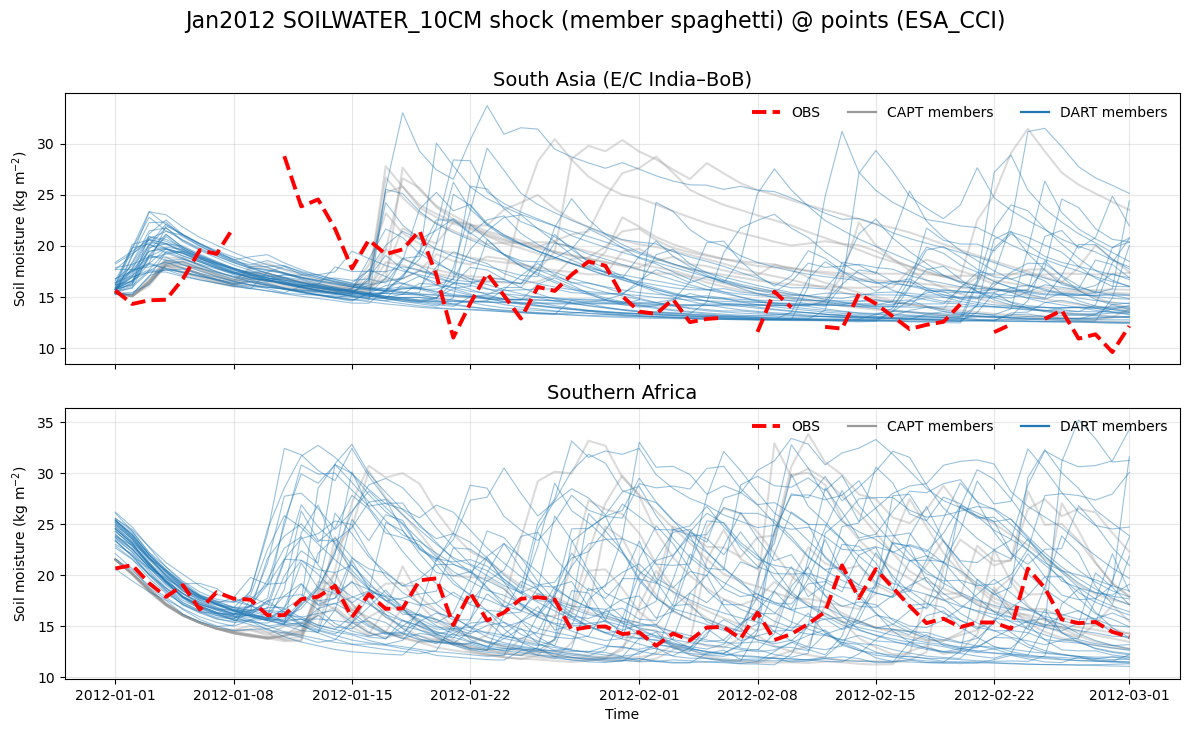

[Jan2012] Saved: soil_point_spaghetti_SAS_SAF_Jan2012_SOILWATER_10CM_201201-201203.png
[Jun2012] Collected variables: ['SOILWATER_10CM']


KeyError: 'CAPT10-S0'

In [21]:
if __name__ == "__main__":
    data_path = "/compyfs/zhan391/v3_dart_cda_scratch"
    fig_path = "./"
    os.makedirs(fig_path, exist_ok=True)

    land_mask = "/compyfs/zhan391/acme_init/lnd_sea_mask/landmask_1x1.nc"
    landmask_var = "landfrac"

    exp_list = {
        "Jan2012": dict(
            models=["CTRL10-S0", "CAPT10-S0", "DART20-S0", "DART40-S0"],
            period="201201-201203",
            season="Winter",
            init_month=1,
        ),
        "Jun2012": dict(
            models=["CTRL10-S1", "CAPT10-S1", "DART40-S1"],
            period="201206-201208",
            season="Summer",
            init_month=6,
        ),
    }

    # model_var -> obs_var
    obs_key = "ESA_CCI"
    lnd_var_map = {"SOILWATER_10CM": "H2OSOI"}

    model_var_name = "SOILWATER_10CM"
    obs_var_name = "H2OSOI"
    depth_cm = 10.0
    mask_land = False

    freq = "daily"
    run = "fc"

    # collector settings (must match filenames!)
    model_template = "%(var)s.%(ens)s.%(year)d.nc"
    ens_prefix = "EN"
    ens_width = 2
    ens_start = 1

    # ------------------------------------------------------------
    # Points to extract (EDIT HERE to change points)
    # ------------------------------------------------------------
    points = {
        "SOUTH_ASIA_MONSOON": dict(
            name="South Asia (E/C India–BoB)",
            lat=20.0,
            lon=85.0,
        ),
        "SOUTHERN_AFRICA": dict(
            name="Southern Africa",
            lat=-22.0,
            lon=28.0,
        ),
    }

    # If None -> plot all exps in each group
    exps_to_plot = ["CAPT10-S0", "DART40-S0"]

    # Optional: limit # members plotted for readability
    max_members = None  # e.g. 20

    # ------------------------------------------------------------
    # Cache settings (efficiency)
    # ------------------------------------------------------------
    cache_dir = Path("./point_cache")
    cache_dir.mkdir(parents=True, exist_ok=True)

    # A short tag so changing points doesn't accidentally reuse old cache
    # (edit freely)
    points_tag = "SAS_SAF"

    exp_dict = build_experiments(data_path)

    collector = S2SFileCollector(
        exp_list=exp_list,
        exp_dict=exp_dict,
        obs_registry=OBS_REGISTRY,
        s2s_var_dict=lnd_var_map,
        get_obs_file_func=get_obs_file,
    )

    # ------------------------------------------------------------
    # point extractor config + object
    # ------------------------------------------------------------
    ts_cfg = SoilPointTSConfig(
        model_var_name=model_var_name,
        obs_var_name=obs_var_name,
        depth_cm=depth_cm,
        water_density=1000.0,
        landmask_file=land_mask,
        landmask_var=landmask_var,
        mask_land=mask_land,
    )
    extractor = SoilPointTimeSeriesFromCollectedFiles(ts_cfg)

    for group, meta in exp_list.items():
        period = meta["period"]

        cfg_collect = FileCollectionConfig(
            group=group,
            freq=freq,
            run=run,
            obs=obs_key,
            period=period,
            model_template=model_template,
            ens_prefix=ens_prefix,
            ens_width=ens_width,
            ens_start=ens_start,
        )

        all_files = collector.collect(cfg_collect, verbose=True)
        print(f"[{group}] Collected variables: {list(all_files.keys())}")

        this_exps = meta["models"] if exps_to_plot is None else exps_to_plot

        for model_var, obs_var in lnd_var_map.items():
            if model_var not in all_files:
                continue

            # --------------------------------------------------------
            # 1) Build / reuse cached point dataset
            # --------------------------------------------------------
            cache_nc = cache_dir / f"soil_point_cache_{points_tag}_{group}_{model_var}_{period}_{obs_key}.nc"

            if cache_nc.exists():
                print(f"[{group}] Using cached point data: {cache_nc}")
            else:
                saved = extractor.save_collected(
                    all_files[model_var],
                    points=points,
                    obs_key=obs_key,
                    exp_order=this_exps,
                    out_nc=cache_nc,
                    overwrite=False,
                )
                print(f"[{group}] Saved cached point data: {saved}")

            # --------------------------------------------------------
            # 2) Plot spaghetti from cached data (shock-focused)
            # --------------------------------------------------------
            ds_cached = extractor.open_collected(cache_nc)

            out_png = Path(fig_path) / f"soil_point_spaghetti_{points_tag}_{group}_{model_var}_{period}.png"
            extractor.plot_spaghetti(
                ds_cached,
                exps=this_exps,
                out_png=out_png,
                show=True,
                title=f"{group} {model_var} shock (member spaghetti) @ points ({obs_key})",
                max_members=max_members,
            )
            print(f"[{group}] Saved: {out_png}")


[Jan2012] Collected variables: ['SOILWATER_10CM']


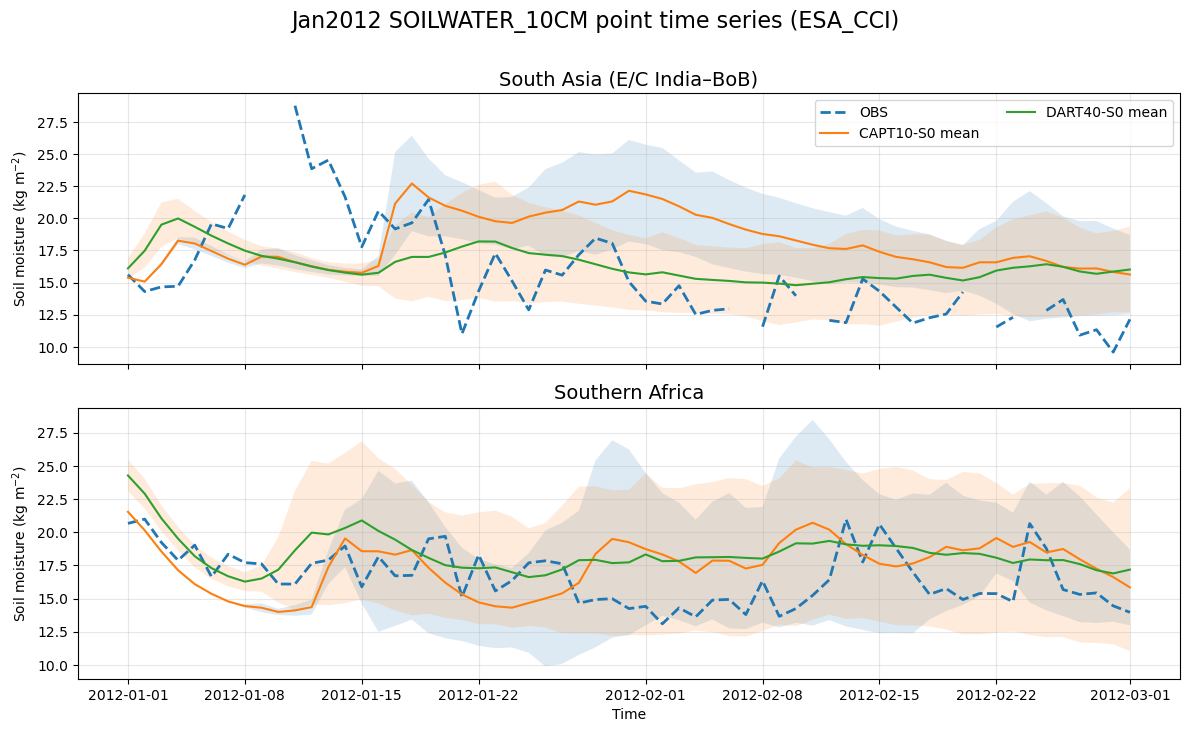

[Jan2012] Saved: soil_point_ts_Jan2012_SOILWATER_10CM_201201-201203.png
[Jun2012] Collected variables: ['SOILWATER_10CM']


KeyError: 'CAPT10-S0'

In [11]:
if __name__ == "__main__":
    data_path = "/compyfs/zhan391/v3_dart_cda_scratch"
    fig_path = "./"
    os.makedirs(fig_path, exist_ok=True)

    land_mask = "/compyfs/zhan391/acme_init/lnd_sea_mask/landmask_1x1.nc"
    landmask_var = "landfrac"

    exp_list = {
        "Jan2012": dict(
            models=["CTRL10-S0", "CAPT10-S0", "DART20-S0", "DART40-S0"],
            period="201201-201203",
            season="Winter",
            init_month=1,
        ),
        "Jun2012": dict(
            models=["CTRL10-S1", "CAPT10-S1", "DART40-S1"],
            period="201206-201208",
            season="Summer",
            init_month=6,
        ),
    }

    # model_var -> obs_var
    obs_key = "ESA_CCI"
    lnd_var_map = {"SOILWATER_10CM": "H2OSOI"}

    model_var_name = "SOILWATER_10CM"
    obs_var_name = "H2OSOI"
    depth_cm = 10.0
    mask_land = False

    freq = "daily"
    run = "fc"

    # collector settings (must match filenames!)
    model_template = "%(var)s.%(ens)s.%(year)d.nc"
    ens_prefix = "EN"
    ens_width = 2
    ens_start = 1

    exp_dict = build_experiments(data_path)

    collector = S2SFileCollector(
        exp_list=exp_list,
        exp_dict=exp_dict,
        obs_registry=OBS_REGISTRY,
        s2s_var_dict=lnd_var_map,
        get_obs_file_func=get_obs_file,
    )

    # ------------------------------------------------------------
    # Points to extract (EDIT HERE to change points)
    # ------------------------------------------------------------
    points = {
        "SOUTH_ASIA_MONSOON": dict(
            name="South Asia (E/C India–BoB)",
            lat=20.0,
            lon=85.0,
        ),
        "SOUTHERN_AFRICA": dict(
            name="Southern Africa",
            lat=-22.0,
            lon=28.0,
        ),
    }

    # If None -> plot all exps in each group
    exps_to_plot = ["CAPT10-S0", "DART40-S0"]

    # ------------------------------------------------------------
    # point extractor config + object
    # ------------------------------------------------------------
    ts_cfg = SoilPointTSConfig(
        model_var_name=model_var_name,
        obs_var_name=obs_var_name,
        depth_cm=depth_cm,               # <-- FIX: comma
        water_density=1000.0,            # optional but good
        landmask_file=land_mask,
        landmask_var=landmask_var,
        mask_land=mask_land,
    )
    extractor = SoilPointTimeSeriesFromCollectedFiles(ts_cfg)

    for group, meta in exp_list.items():
        period = meta["period"]

        cfg_collect = FileCollectionConfig(
            group=group,
            freq=freq,
            run=run,
            obs=obs_key,
            period=period,
            model_template=model_template,
            ens_prefix=ens_prefix,
            ens_width=ens_width,
            ens_start=ens_start,
        )

        all_files = collector.collect(cfg_collect, verbose=True)
        print(f"[{group}] Collected variables: {list(all_files.keys())}")

        # decide experiments for THIS group
        if exps_to_plot is None:
            this_exps = meta["models"]
        else:
            this_exps = exps_to_plot

        for model_var, obs_var in lnd_var_map.items():
            if model_var not in all_files:
                continue

            ds_ts = extractor.compute(
                all_files[model_var],
                points=points,
                obs_key=obs_key,
                exp_order=this_exps,
            )

            out_png = Path(fig_path) / f"soil_point_ts_{group}_{model_var}_{period}.png"
            extractor.plot(
                ds_ts,
                exps=this_exps,
                out_png=out_png,
                show=True,
                title=f"{group} {model_var} point time series ({obs_key})",
            )

            print(f"[{group}] Saved: {out_png}")
            